# Day 3｜AI 新品上市策略、動態定價與營收優化

## 從價格實驗到營收與風險情境

> **資料使用邊界：** 本 Notebook 使用固定亂數種子產生的教學虛擬資料，不是任何企業的真實營運資料。結果只能用於練習分析流程，不可宣稱為企業事實或因果效果。

### 故事情境

上市會議只剩一天。四家企業都提出三種價格：雜草町擔心高價破壞親近感；義大要在套票吸引力與跨場域收入間取捨；盛香珍要平衡通路價格、成本與聯名價值；寶島眼鏡要兼顧商品、服務與會員方案。主管要求的不是『最高價』，而是一個可算、可測、可停損的上市方案。

### 今日決策問題

**在價格、行銷、通路與成本假設下，哪一個上市方案最值得先測試？**

### 學習目標

- 能計算營收、毛利、貢獻毛利與損益平衡
- 能以 log-log 模型近似價格彈性並說明限制
- 能建立含類別變數與交互作用的預測模型
- 能完成低／基準／高三情境模擬
- 能提出可停損的價格實驗

### Colab 操作提醒

1. 在 Google Drive 建立個人副本。
2. 將對應 CSV 上傳到 Colab `/content`，或保持教材包原始相對路徑。
3. 由上到下依序執行；若 Runtime 重啟，請重新執行全部儲存格。
4. 每個程式碼儲存格後都有繁體中文說明、預期輸出與完成檢核。

> **明志科技大學 M4｜盛香珍 × 亙美質珍 專屬 Notebook**
>
> 教學設計與教材製作｜恩恩統計家教
>
> www.enentutor.com

#### 第一次使用 Google Colab

1. 登入 Google 帳號後，選擇「檔案 → 在雲端硬碟中儲存副本」。
2. 依頁面順序按儲存格左側播放鍵；也可按 `Shift+Enter` 執行目前儲存格。
3. 星號表示正在執行，綠色勾選表示完成；看到紅字時先讀最末一行。
4. 若執行順序混亂，選擇「執行階段 → 重新啟動工作階段並全部執行」。
5. 本 Notebook 已綁定 盛香珍 × 亙美質珍，不需修改企業名稱；Raw 失敗時才上傳同企業 CSV 到 `/content`。

### [D3-S01] 把『訂一個價格』改寫成可驗證的上市決策

In [1]:
# 本格目的：載入套件並找到教學資料檔
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# 中文圖表字型設定（Windows／macOS／Linux／Google Colab）
import hashlib
import os
import sys
from pathlib import Path
from urllib.request import urlretrieve
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.ft2font import FT2Font

FONT_URL = "https://raw.githubusercontent.com/notofonts/noto-cjk/f8d157532fbfaeda587e826d4cd5b21a49186f7c/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
FONT_SHA256 = "dce08bd4fd91aa8aa76ed8fea4b694c2dfb8550f67871e326843212ddbeb88b4"
font_override = os.environ.get("M4_FONT_PATH")
FONT_FILE_CANDIDATES = [
    *([Path(font_override)] if font_override else []),
    Path("C:/Windows/Fonts/msjh.ttc"),
    Path("C:/Windows/Fonts/msjhbd.ttc"),
    Path("/usr/share/fonts/opentype/noto/NotoSansCJKtc-Regular.otf"),
    Path("/usr/share/fonts/truetype/noto/NotoSansTC-Regular.ttf"),
    Path("/usr/local/share/fonts/NotoSansTC-Regular.ttf"),
    Path("/System/Library/Fonts/PingFang.ttc"),
]

font_path = next((path for path in FONT_FILE_CANDIDATES if path.is_file()), None)
in_colab = (
    "google.colab" in sys.modules
    or "COLAB_RELEASE_TAG" in os.environ
    or "COLAB_BACKEND_VERSION" in os.environ
    or Path("/content").is_dir()
)
allow_download = in_colab or os.environ.get("M4_DOWNLOAD_CJK_FONT") == "1"
if font_path is None and allow_download:
    font_cache = Path("/content/.cache/m4-fonts") if in_colab else Path.home() / ".cache" / "m4-fonts"
    font_cache.mkdir(parents=True, exist_ok=True)
    downloaded_font = font_cache / "NotoSansCJKtc-Regular.otf"
    if downloaded_font.is_file() and hashlib.sha256(downloaded_font.read_bytes()).hexdigest() != FONT_SHA256:
        downloaded_font.unlink()
    if not downloaded_font.is_file():
        temporary_font = downloaded_font.with_suffix(".download")
        temporary_font.unlink(missing_ok=True)
        try:
            urlretrieve(FONT_URL, temporary_font)
        except (OSError, ValueError) as exc:
            temporary_font.unlink(missing_ok=True)
            raise RuntimeError("無法下載免費的 Noto Sans TC 字型，請確認網路後重新執行本格。") from exc
        if hashlib.sha256(temporary_font.read_bytes()).hexdigest() != FONT_SHA256:
            temporary_font.unlink(missing_ok=True)
            raise RuntimeError("下載的 Noto Sans TC 字型檔驗證失敗，請重新執行本格。")
        temporary_font.replace(downloaded_font)
    font_path = downloaded_font

if font_path is None:
    raise RuntimeError(
        "找不到可顯示繁體中文的字型；本機請安裝免費的 Noto Sans TC，"
        "或設定 M4_FONT_PATH 指向字型檔。"
    )

font_path = font_path.resolve()
try:
    # 使用公開 API，把實際字型檔加入「目前這次執行」的 FontManager。
    font_manager.fontManager.addfont(str(font_path))
except (OSError, RuntimeError) as exc:
    raise RuntimeError(f"Matplotlib 無法載入中文字型檔：{font_path}") from exc

registered_font = next(
    (
        entry
        for entry in reversed(font_manager.fontManager.ttflist)
        if Path(entry.fname).resolve() == font_path
    ),
    None,
)
if registered_font is None:
    raise RuntimeError(f"中文字型未成功註冊到目前的 Matplotlib：{font_path}")
font_name = registered_font.name

font_rc = {
    "font.family": font_name,
    "font.sans-serif": [font_name],
    "axes.unicode_minus": False,
}
sns.set_theme(style="whitegrid", rc=font_rc)
mpl.rcParams.update(font_rc)

# 驗證 Matplotlib 真的能用已註冊的名稱找到字型，而且含課程常用繁中文字元。
try:
    resolved_font = font_manager.findfont(
        font_manager.FontProperties(family=[font_name]),
        fallback_to_default=False,
    )
except ValueError as exc:
    raise RuntimeError(f"Matplotlib 找不到剛註冊的中文字型：{font_name}") from exc
font_face = FT2Font(resolved_font)
required_text = "繁體中文圖表標題座標軸月份需求價格廣告預測實際值"
missing_glyphs = sorted(
    {char for char in required_text if font_face.get_char_index(ord(char)) == 0}
)
if missing_glyphs:
    raise RuntimeError(f"中文字型缺少必要字元：{missing_glyphs}")

# Plotly 若已安裝，同步設定預設範本；未安裝時不增加課堂錯誤。
try:
    import plotly.io as pio

    pio.templates.default = "plotly_white"
    pio.templates["plotly_white"].layout.font.family = f'"{font_name}", sans-serif'
except (ImportError, KeyError, AttributeError):
    pass
print(f"圖表中文字型：{font_name}（{resolved_font}）")

# 優先從公開 GitHub Raw 讀取企業專屬資料；失敗時再依序尋找 /content 與本機相對路徑
import os

ENTERPRISE_ID = "shengxiangzhen-genmei"
ENTERPRISE_NAME = "盛香珍X亙美質珍"
ENTERPRISE_DISPLAY_NAME = "盛香珍 × 亙美質珍"
RAW_DATA_URL = "https://raw.githubusercontent.com/johnnychao/mcut-m4-business-analytics-2026-student/main/docs/resources/data/shengxiangzhen-genmei/day-3-shengxiangzhen-genmei-launch-pricing.csv"
DATA_FILENAME = "day-3-shengxiangzhen-genmei-launch-pricing.csv"
FORCE_LOCAL_DATA = os.environ.get("M4_FORCE_LOCAL_DATA") == "1"

try:
    # 正式教材 QA 可關閉遠端來源，確認企業專屬本機資料能獨立運作
    if FORCE_LOCAL_DATA:
        raise ConnectionError("M4 Notebook QA：改用本機資料備援")
    df = pd.read_csv(RAW_DATA_URL)
    data_source = RAW_DATA_URL
except Exception as remote_error:
    candidate_paths = [
        Path("/content") / DATA_FILENAME,
        Path(DATA_FILENAME),
        Path("../04_data") / ENTERPRISE_ID / DATA_FILENAME,
        Path("../../04_data") / ENTERPRISE_ID / DATA_FILENAME,
    ]
    data_path = next((path for path in candidate_paths if path.exists()), None)
    if data_path is None:
        raise FileNotFoundError(
            f"GitHub Raw 暫時無法讀取，而且 /content 與本機相對路徑都找不到 {DATA_FILENAME}。"
        ) from remote_error
    df = pd.read_csv(data_path)
    data_source = str(data_path)

# 企業專屬 CSV 應只有一家公司；若不一致就立即停止，避免跨企業混算
if df["company"].nunique() != 1 or str(df["company"].iloc[0]) != ENTERPRISE_NAME:
    raise ValueError(f"資料企業不符：預期 {ENTERPRISE_NAME}，實際 {df['company'].unique().tolist()}")

# 所有課堂匯出檔依企業集中，避免 16 本 Notebook 的輸出互相覆蓋
OUTPUT_DIR = Path("outputs") / ENTERPRISE_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"企業情境：{ENTERPRISE_DISPLAY_NAME}")
print(f"資料來源：{data_source}")
print(f"資料尺寸：{df.shape}")
display(df.head(3))

圖表中文字型：Microsoft JhengHei
企業情境：盛香珍 × 亙美質珍
資料來源：..\04_data\shengxiangzhen-genmei\day-3-shengxiangzhen-genmei-launch-pricing.csv
資料尺寸：(240, 15)


,date,company,offer,channel,segment,price,base_price,discount_rate,marketing_spend,competitor_price_index,holiday_flag,units_sold,unit_cost,fixed_cost,is_synthetic
0,2025-01-06,盛香珍X亙美質珍,經典小泡芙,online,新客,76.250,86.400,0.117,839.250,1.049,0,1195,41.240,"2,160.000",True
1,2025-01-13,盛香珍X亙美質珍,限定風味小泡芙,store,新客,91.050,105.600,0.138,"1,152.250",1.017,0,1227,50.390,"2,640.000",True
2,2025-01-20,盛香珍X亙美質珍,分享派對包,event,新客,111.950,124.800,0.103,"1,399.750",0.924,0,1308,57.480,"3,120.000",True


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 載入價格實驗虛擬資料。
- **預期輸出：** 資料尺寸與前三列。
- **完成檢核：** 資料包含四家公司與虛擬標記。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D3-S02] 確認綁定企業並算清楚營收、毛利與單位貢獻

In [2]:
# 本格目的：篩選企業並計算營收、毛利與單位貢獻
assert df["is_synthetic"].astype(str).str.lower().eq("true").all()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["marketing_spend"] = df.groupby("company")["marketing_spend"].transform(lambda s: s.fillna(s.median()))

# 本 Notebook 已由網站企業卡片綁定唯一企業，不需再次選擇
company_df = df.copy()
assert company_df["company"].nunique() == 1 and not company_df.empty

company_df["revenue"] = company_df["price"] * company_df["units_sold"]
company_df["gross_profit"] = (company_df["price"] - company_df["unit_cost"]) * company_df["units_sold"]
company_df["unit_contribution"] = company_df["price"] - company_df["unit_cost"]
company_df["gross_margin_rate"] = company_df["gross_profit"] / company_df["revenue"]
display(company_df[["offer", "price", "units_sold", "revenue", "gross_profit", "gross_margin_rate"]].head().round(2))

,offer,price,units_sold,revenue,gross_profit,gross_margin_rate
0,經典小泡芙,76.250,1195,"91,118.750","41,836.950",0.460
1,限定風味小泡芙,91.050,1227,"111,718.350","49,889.820",0.450
2,分享派對包,111.950,1308,"146,430.600","71,246.760",0.490
3,跨界聯名禮盒,122.900,1580,"194,182.000","84,308.800",0.430
4,經典小泡芙,74.140,1700,"126,038.000","59,551.000",0.470


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 只保留一家企業，補足教學缺失值並建立營收、毛利、貢獻與毛利率。
- **預期輸出：** 含衍生財務欄位的樣本表。
- **完成檢核：** 單位貢獻應等於 price 減 unit_cost；資料仍標示為虛擬。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D3-S03] 用分層圖探索價格與銷量，不把混雜誤認為價格效果

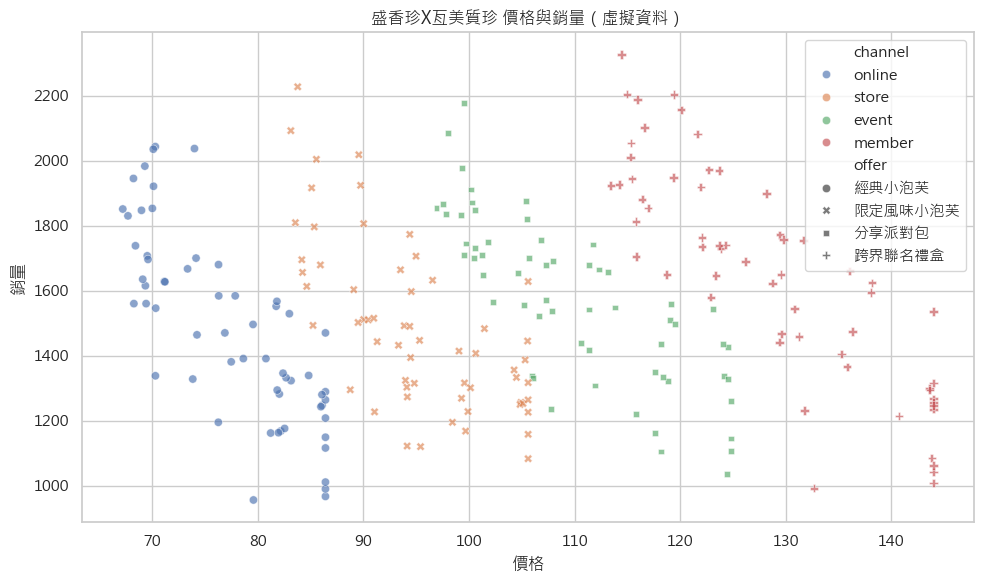

,min_price,max_price,mean_units,total_revenue,total_gross_profit
offer,,,,,
跨界聯名禮盒,113.420,144.000,"1,650.500","12,544,641.630","5,688,208.700"
分享派對包,96.920,124.800,"1,569.930","10,250,886.460","4,577,220.610"
限定風味小泡芙,83.120,105.600,"1,485.920","8,393,573.030","3,863,715.540"
經典小泡芙,67.200,86.400,"1,479.150","6,780,555.870","3,100,354.470"


In [3]:
# 本格目的：分通路觀察價格與銷量的樣本關聯
plt.figure(figsize=(10, 6))
sns.scatterplot(data=company_df, x="price", y="units_sold", hue="channel", style="offer", alpha=0.65)
plt.title(f"{ENTERPRISE_NAME} 價格與銷量（虛擬資料）")
plt.xlabel("價格")
plt.ylabel("銷量")
plt.tight_layout()
plt.show()

price_summary = company_df.groupby("offer").agg(
    min_price=("price", "min"), max_price=("price", "max"),
    mean_units=("units_sold", "mean"), total_revenue=("revenue", "sum"),
    total_gross_profit=("gross_profit", "sum"),
).sort_values("total_gross_profit", ascending=False)
display(price_summary.round(2))

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以通路和商品分層觀察價格與銷量，避免把四種商品的量級差異誤當價格效果。
- **預期輸出：** 價格散點圖與商品財務摘要。
- **完成檢核：** 只寫關聯，不宣稱調價造成銷量變化。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D3-S04] 用 log-log 模型近似價格彈性並守住因果邊界

In [4]:
# 本格目的：以 log-log 迴歸近似樣本內價格敏感度
from sklearn.linear_model import LinearRegression

elasticity_rows = []
for offer, group in company_df.groupby("offer"):
    safe_group = group.loc[(group["price"] > 0) & (group["units_sold"] > 0)].copy()
    elasticity_model = LinearRegression().fit(np.log(safe_group[["price"]]), np.log(safe_group["units_sold"]))
    elasticity_rows.append({"offer": offer, "elasticity_approx": elasticity_model.coef_[0], "n": len(safe_group)})
elasticity_table = pd.DataFrame(elasticity_rows)
elasticity_table["warning"] = "觀察資料關聯近似；不是因果價格效果"
display(elasticity_table.round(3))

,offer,elasticity_approx,n,warning
0,分享派對包,-1.608,60,觀察資料關聯近似；不是因果價格效果
1,經典小泡芙,-1.749,60,觀察資料關聯近似；不是因果價格效果
2,跨界聯名禮盒,-2.266,60,觀察資料關聯近似；不是因果價格效果
3,限定風味小泡芙,-1.516,60,觀察資料關聯近似；不是因果價格效果


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 對每個商品分開建立 log(price) 對 log(units) 的簡單模型，係數作為彈性近似。
- **預期輸出：** 四個商品的彈性近似值。
- **完成檢核：** 每一列保留非因果警語；不要跨商品直接比較絕對價格。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D3-S05] 以時間切分與 Pipeline 建立銷量預測 baseline

In [5]:
# 本格目的：同時考慮價格、行銷、競品、節慶與類別差異
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures

numeric_features = ["price", "marketing_spend", "competitor_price_index", "holiday_flag"]
categorical_features = ["offer", "channel", "segment"]
unique_dates = np.array(sorted(company_df["date"].unique()))
cutoff_date = unique_dates[int(len(unique_dates) * 0.80)]
train_df = company_df.loc[company_df["date"] < cutoff_date].copy()
test_df = company_df.loc[company_df["date"] >= cutoff_date].copy()

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
pricing_model = Pipeline([("preprocess", preprocess), ("model", LinearRegression())])
pricing_model.fit(train_df[numeric_features + categorical_features], train_df["units_sold"])
test_df["predicted_units"] = np.maximum(0, pricing_model.predict(test_df[numeric_features + categorical_features]))
print(f"切分日期：{pd.Timestamp(cutoff_date).date()}；訓練 {len(train_df)}；測試 {len(test_df)}")

切分日期：2025-08-18；訓練 192；測試 48


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 按日期切分後，使用數值與類別變數預測銷量；所有前處理都在 Pipeline 中。
- **預期輸出：** 切分日期與訓練／測試筆數。
- **完成檢核：** 測試日期晚於訓練日期；預測值非負。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D3-S06] 用 MAE、RMSE、R² 與預測圖判斷模型能不能支援試算

,MAE,RMSE,R2
0,122.437,164.978,0.683


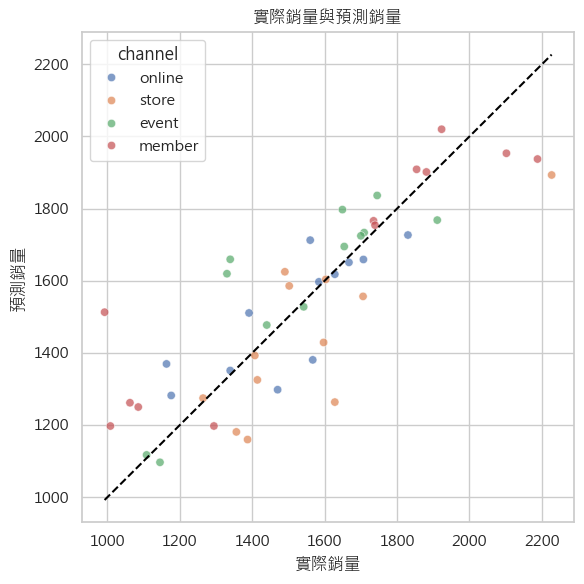

限制：此模型用於虛擬資料預測與情境練習，不是調價因果估計。


In [6]:
# 本格目的：用未見資料誤差判斷模型是否足以進行情境試算
pricing_metrics = pd.DataFrame([{
    "MAE": mean_absolute_error(test_df["units_sold"], test_df["predicted_units"]),
    "RMSE": mean_squared_error(test_df["units_sold"], test_df["predicted_units"]) ** 0.5,
    "R2": r2_score(test_df["units_sold"], test_df["predicted_units"]),
}])
display(pricing_metrics.round(3))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=test_df, x="units_sold", y="predicted_units", hue="channel", alpha=0.7)
line_min = min(test_df["units_sold"].min(), test_df["predicted_units"].min())
line_max = max(test_df["units_sold"].max(), test_df["predicted_units"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
plt.title("實際銷量與預測銷量")
plt.xlabel("實際銷量")
plt.ylabel("預測銷量")
plt.tight_layout()
plt.show()
print("限制：此模型用於虛擬資料預測與情境練習，不是調價因果估計。")

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 計算 MAE、RMSE、R² 並檢查實際值對預測值散點。
- **預期輸出：** 一列評估指標與一張散點圖。
- **完成檢核：** 能用需求單位說明 MAE，並保留非因果限制。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D3-S07] 建立 95%、100%、108% 候選價格網格，避免過度外插

In [7]:
# 本格目的：在歷史價格附近比較三個候選價格，不做過度外插
scenario_rows = []
for offer, group in company_df.groupby("offer"):
    latest = group.sort_values("date").iloc[-1].copy()
    reference_price = group["base_price"].median()
    for price_factor in [0.95, 1.00, 1.08]:
        row = latest.copy()
        row["price"] = reference_price * price_factor
        scenario_rows.append(row)
scenario_df = pd.DataFrame(scenario_rows)
scenario_df["predicted_units"] = np.maximum(0, pricing_model.predict(scenario_df[numeric_features + categorical_features]))
scenario_df["revenue"] = scenario_df["price"] * scenario_df["predicted_units"]
scenario_df["gross_profit"] = (scenario_df["price"] - scenario_df["unit_cost"]) * scenario_df["predicted_units"]
display(scenario_df[["offer", "price", "predicted_units", "revenue", "gross_profit"]].round(2))

,offer,price,predicted_units,revenue,gross_profit
238,分享派對包,118.560,"1,263.190","149,763.480","74,730.160"
238,分享派對包,124.800,"1,096.490","136,841.510","71,710.210"
238,分享派對包,134.780,829.770,"111,839.070","62,551.020"
236,經典小泡芙,82.080,"1,342.290","110,175.550","56,242.150"
236,經典小泡芙,86.400,"1,226.890","106,002.990","56,706.690"
236,經典小泡芙,93.310,"1,042.230","97,252.870","55,375.940"
239,跨界聯名禮盒,136.800,"1,380.180","188,808.880","93,686.750"
239,跨界聯名禮盒,144.000,"1,187.830","171,048.220","89,182.640"
239,跨界聯名禮盒,155.520,880.080,"136,869.970","76,214.890"
237,限定風味小泡芙,100.320,"1,274.200","127,828.000","63,174.960"


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以各商品基準價的 95%、100%、108% 建立透明候選方案。
- **預期輸出：** 每商品三個價格的預測銷量、營收與毛利。
- **完成檢核：** 候選價接近資料範圍；沒有宣稱最高預測毛利是唯一答案。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D3-S08] 展開三情境、計算損益平衡並找出方案翻盤點

In [8]:
# 本格目的：把需求與成本不確定性攤開，檢查方案是否撐得住
scenario_settings = pd.DataFrame([
    {"scenario": "保守", "demand_factor": 0.80, "cost_factor": 1.08},
    {"scenario": "基準", "demand_factor": 1.00, "cost_factor": 1.00},
    {"scenario": "樂觀", "demand_factor": 1.15, "cost_factor": 0.98},
])
expanded = scenario_df.merge(scenario_settings, how="cross")
expanded["scenario_units"] = expanded["predicted_units"] * expanded["demand_factor"]
expanded["scenario_unit_cost"] = expanded["unit_cost"] * expanded["cost_factor"]
expanded["scenario_revenue"] = expanded["price"] * expanded["scenario_units"]
expanded["scenario_gross_profit"] = (expanded["price"] - expanded["scenario_unit_cost"]) * expanded["scenario_units"]
expanded["unit_contribution"] = expanded["price"] - expanded["scenario_unit_cost"]
expanded["break_even_units"] = np.where(
    expanded["unit_contribution"] > 0,
    np.ceil(expanded["fixed_cost"] / expanded["unit_contribution"]),
    np.nan,
)
display(expanded[["offer", "price", "scenario", "scenario_units", "scenario_revenue", "scenario_gross_profit", "break_even_units"]].round(2))

,offer,price,scenario,scenario_units,scenario_revenue,scenario_gross_profit,break_even_units
0,分享派對包,118.560,保守,"1,010.550","119,810.780","54,981.990",58.000
1,分享派對包,118.560,基準,"1,263.190","149,763.480","74,730.160",53.000
2,分享派對包,118.560,樂觀,"1,452.670","172,228.000","87,665.450",52.000
3,分享派對包,124.800,保守,877.190,"109,473.210","53,199.770",52.000
4,分享派對包,124.800,基準,"1,096.490","136,841.510","71,710.210",48.000
5,分享派對包,124.800,樂觀,"1,260.960","157,367.730","83,964.760",47.000
6,分享派對包,134.780,保守,663.810,"89,471.260","46,886.380",45.000
7,分享派對包,134.780,基準,829.770,"111,839.070","62,551.020",42.000
8,分享派對包,134.780,樂觀,954.230,"128,614.930","73,067.300",41.000
9,經典小泡芙,82.080,保守,"1,073.840","88,140.440","41,541.980",56.000


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 將每個價格擴充成保守、基準、樂觀需求／成本情境，並計算損益平衡量。
- **預期輸出：** 每商品九格情境表。
- **完成檢核：** 若單位貢獻不為正，損益平衡量為缺值而非硬算。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D3-S09] 整理上市方案成果草稿與繳交前檢核

In [9]:
# 本格目的：以基準與保守情境同時檢查，不只挑最高營收
summary = expanded.groupby(["offer", "price"], as_index=False).agg(
    mean_gross_profit=("scenario_gross_profit", "mean"),
    worst_gross_profit=("scenario_gross_profit", "min"),
    mean_break_even=("break_even_units", "mean"),
)
recommended = summary.sort_values(["worst_gross_profit", "mean_gross_profit"], ascending=False).groupby("offer").head(1)
recommended["recommendation"] = "先小規模測試；連續兩期毛利低於保守情境即停損"
recommended["warning"] = "虛擬資料情境，不是上線動態定價指令"
display(recommended.round(2))
recommended.to_csv(OUTPUT_DIR / "Day3_上市價格測試建議.csv", index=False, encoding="utf-8-sig")

,offer,price,mean_gross_profit,worst_gross_profit,mean_break_even,recommendation,warning
6,跨界聯名禮盒,136.800,"90,825.300","68,861.580",54.670,先小規模測試；連續兩期毛利低於保守情境即停損,虛擬資料情境，不是上線動態定價指令
0,分享派對包,118.560,"72,459.200","54,981.990",54.330,先小規模測試；連續兩期毛利低於保守情境即停損,虛擬資料情境，不是上線動態定價指令
9,限定風味小泡芙,100.320,"61,238.450","46,402.170",55.000,先小規模測試；連續兩期毛利低於保守情境即停損,虛擬資料情境，不是上線動態定價指令
4,經典小泡芙,86.400,"55,087.860","42,210.390",48.000,先小規模測試；連續兩期毛利低於保守情境即停損,虛擬資料情境，不是上線動態定價指令


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以最差情境與平均毛利共同排序，形成可停損的價格測試候選。
- **預期輸出：** 每商品一列建議與警語。
- **完成檢核：** 決策包含測試與停損，不把模型直接當自動調價引擎。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

## 當日學習驗收

正式作答請由課程網站進入當日 Google Form。本區只供你先確認題意與個人繳交內容，請勿在 Notebook 尋找或記錄正確選項。

### 10 題選擇題

#### 第 1 題｜基礎｜容易

某方案成交價 1,200 元、單位變動成本 700 元、預測銷量 40，教學簡化毛利是多少？

- A. 20,000 元
- B. 28,000 元
- C. 48,000 元
- D. 76,000 元

#### 第 2 題｜基礎｜容易

損益平衡銷量的正確分母是什麼？

- A. 成交價格
- B. 單位變動成本
- C. 單位貢獻毛利
- D. 總營收

#### 第 3 題｜基礎｜容易

log-log 模型的價格係數為 -1.2，最合適的解讀是？

- A. 價格每增加 1 元，銷量少 1.2 個
- B. 價格相差 1% 時，樣本銷量平均呈反向約 1.2% 的關聯
- C. 降價 20% 一定讓真實銷量增加 24%
- D. 模型準確率為 120%

#### 第 4 題｜情境應用｜容易

兩個候選價的預測銷量只差 1.5 單位，但測試 MAE 為 3 單位。最負責任的結論是？

- A. 預測較高者一定更好
- B. 差異小於典型誤差，應保留候選並用小規模實驗驗證
- C. 立即換最複雜模型即可證明
- D. 忽略 MAE，只看 R²

#### 第 5 題｜情境應用｜容易

某保守情境單位貢獻為 -50 元。下列哪個處理正確？

- A. 損平量寫成負數並繼續
- B. 把銷量加倍就能回本
- C. 損平量標示缺值，先修正價格或成本結構
- D. 改看總營收即可

#### 第 6 題｜情境應用｜容易

主管要求預測歷史最高價兩倍的銷量。最適合的回應是？

- A. 模型能輸出就直接採用
- B. 先限制在歷史附近；極端價需另作探索與真實測試
- C. 把負預測改成高值
- D. 刪除測試集以提高 R²

#### 第 7 題｜情境應用｜中等

若你選盛香珍 × 亙美質珍的模型毛利未包含退貨與通路補貼，報告應如何處理？

- A. 仍稱為企業淨利
- B. 隱藏限制以免影響推薦
- C. 標示為簡化毛利，將退貨與補貼列為上線前驗證與情境成本
- D. 把所有未含成本設為零

#### 第 8 題｜輸出判讀｜中等

輸出顯示 MAE=2.936、RMSE=3.713。哪個敘述最合理？

- A. 模型平均約差 2.936%，而且沒有大錯
- B. 模型平均絕對誤差約 2.936 個需求單位，且較大誤差使 RMSE 更高
- C. 模型因果效果為 3.713
- D. 模型準確率為 293.6%

#### 第 9 題｜輸出判讀｜中等

某格 scenario_units=25.21、break_even_units=37、scenario_gross_profit 為正。正確判讀是？

- A. 已回收所有固定成本
- B. 需求低於損平量，雖有正毛利貢獻但可能尚未回收固定成本
- C. 賣越多必定虧越多
- D. 損平量可以忽略

#### 第 10 題｜輸出判讀｜整合

recommended 表先依 worst_gross_profit、再依 mean_gross_profit 排序。這代表什麼？

- A. 演算法證明這是唯一最佳效用
- B. 採取先守住下檔、再比較平均表現的風險偏好
- C. 只最大化營收
- D. 完全忽略情境

## 個人 Colab 實作｜17:20–18:40

使用你在網站選擇的企業專屬 Notebook，先 Restart and Run All，不必從零重建完整定價流程。只調整一個候選價格，或一至兩項需求／成本情境參數，比較營收、簡化毛利與損益平衡量。選出一個先測候選，用 150 字內說明數字證據、停止條件、虛擬資料與非因果限制。

### 個人繳交內容

- 可 Restart and Run All 的企業專屬 Colab 連結
- Notebook 自動產生的候選價格情境表
- 一個先測候選與 150 字內決策摘要

### 繳交前檢查

- 已從「執行階段」重新啟動並全部執行，所有儲存格無紅字。
- Notebook、CSV、圖表與摘要都對應網站所選的同一企業情境。
- 已在 Google Form 貼上可檢視的 Colab 分享網址與自己的決策摘要。
- 摘要有引用核心輸出，也有說明虛擬資料限制與下一步驗證。